In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point, test_summary
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# compiling dfs
# folder = Path('./output/2025-12-15_08h51m33s_reconstr_grid1b')
# folder = Path('./output/2025-12-15_11h28m09s_reconstr_grid1b')
# folder = Path('output/2025-12-15_12h47m56s_reconstr_grid1b2')
folder = Path('output/2025-12-19_14h32m22s_reconstr_grid1b_earlystop')

dev = pd.read_csv(folder/'dev.csv')
test = pd.read_csv(folder/'test.csv')

# folder = Path('./output/reconstr_grid1b2')
# subfolders = ['t1', 't2', 't3']
# dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
# test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs_class = ConfigLookup(
    keys=['embed_dim','hidden_dims'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    # save=True,
)

confs = confs_class.data

# merge with confs
dev = pd.merge(confs, dev,on='config')
test = pd.merge(confs, test,on='config')

In [3]:
dev

,embed_dim,hidden_dims,config,trial,epoch,stage,metric,value
0,32,0,embeddim32_hiddendims0,0,0,train,loss,1.059852
1,32,0,embeddim32_hiddendims0,0,0,train,mse,0.805061
2,32,0,embeddim32_hiddendims0,0,0,train,rmse,0.897252
3,32,0,embeddim32_hiddendims0,0,0,train,mae,0.609862
4,32,0,embeddim32_hiddendims0,0,0,train,r2,0.789984
...,...,...,...,...,...,...,...,...
113455,256,4,embeddim256_hiddendims4,2,142,val,loss,0.290713
113456,256,4,embeddim256_hiddendims4,2,142,val,mse,0.664888
113457,256,4,embeddim256_hiddendims4,2,142,val,rmse,0.815407
113458,256,4,embeddim256_hiddendims4,2,142,val,mae,0.540341


In [4]:
test

,embed_dim,hidden_dims,config,trial,metric,value
0,32,0,embeddim32_hiddendims0,0,loss,0.239889
1,32,0,embeddim32_hiddendims0,0,mse,0.702788
2,32,0,embeddim32_hiddendims0,0,rmse,0.838325
3,32,0,embeddim32_hiddendims0,0,mae,0.572942
4,32,0,embeddim32_hiddendims0,0,r2,0.815390
...,...,...,...,...,...,...
475,256,4,embeddim256_hiddendims4,2,mae,0.553603
476,256,4,embeddim256_hiddendims4,2,r2,0.819505
477,256,4,embeddim256_hiddendims4,2,time,178.864910
478,256,4,embeddim256_hiddendims4,2,num_epochs,142.000000


In [5]:
# test['loss_weights'] = test['loss_weights'].astype(str)
# test

In [6]:
# test_summary(test, save_csv=True, filename=folder/'summary.csv')

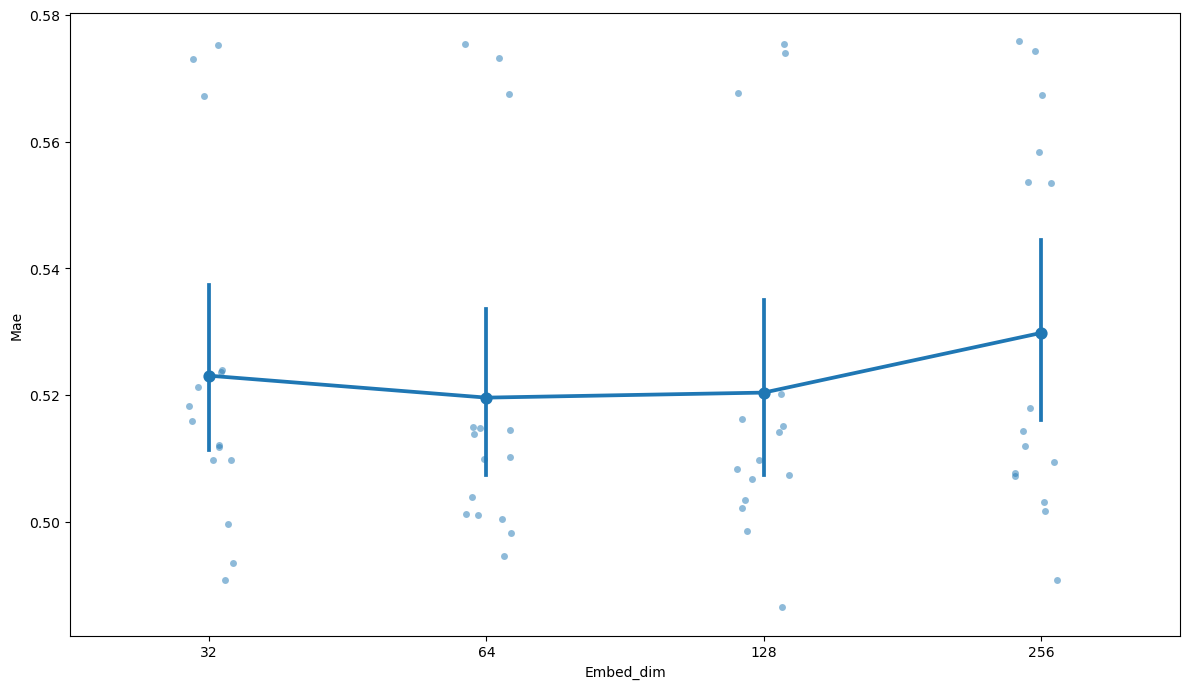

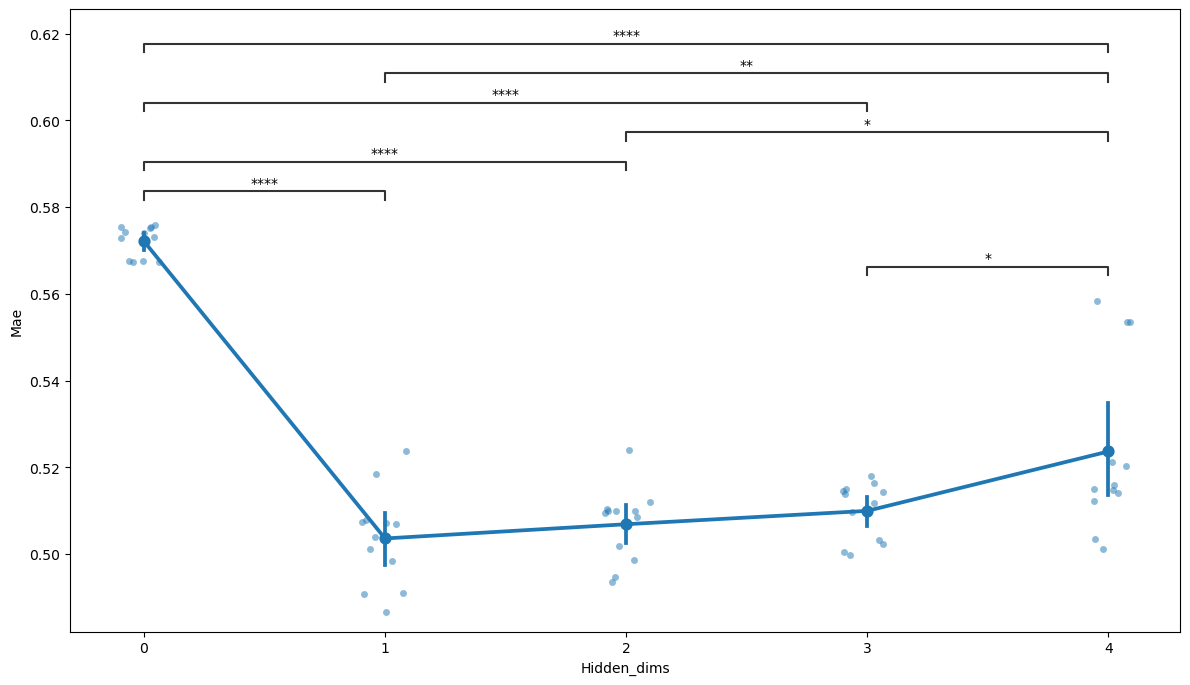

In [7]:
metric_x_point(
    df=test, 
    cols=['embed_dim','hidden_dims'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig=True
)

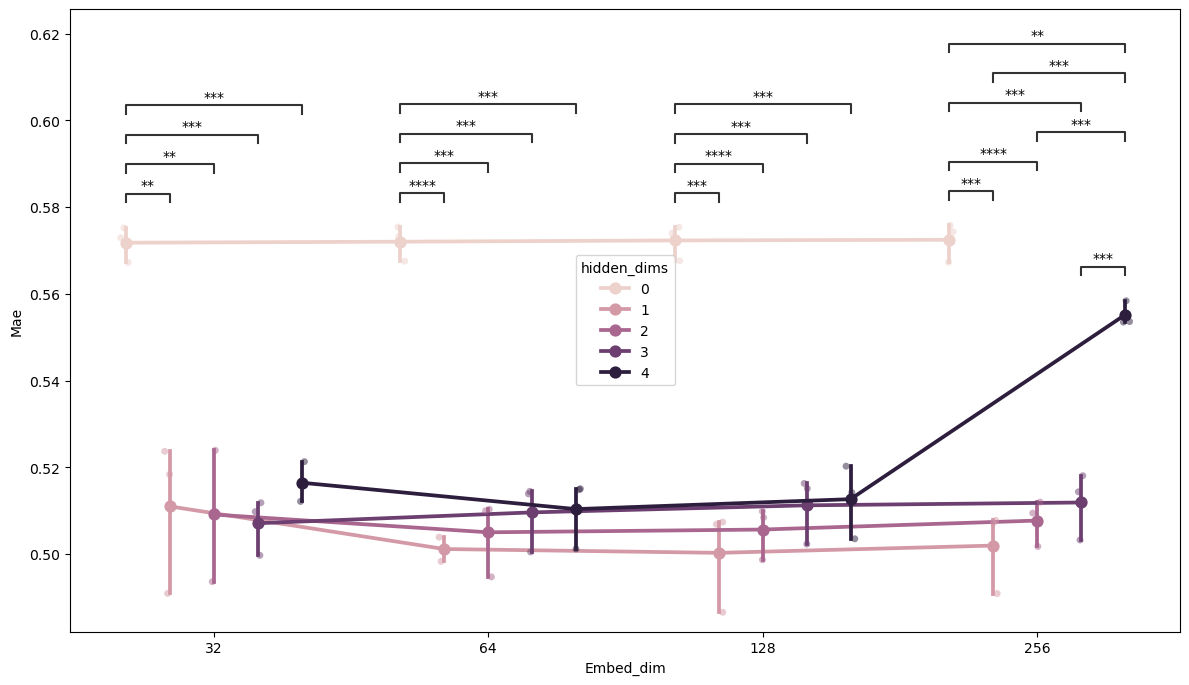

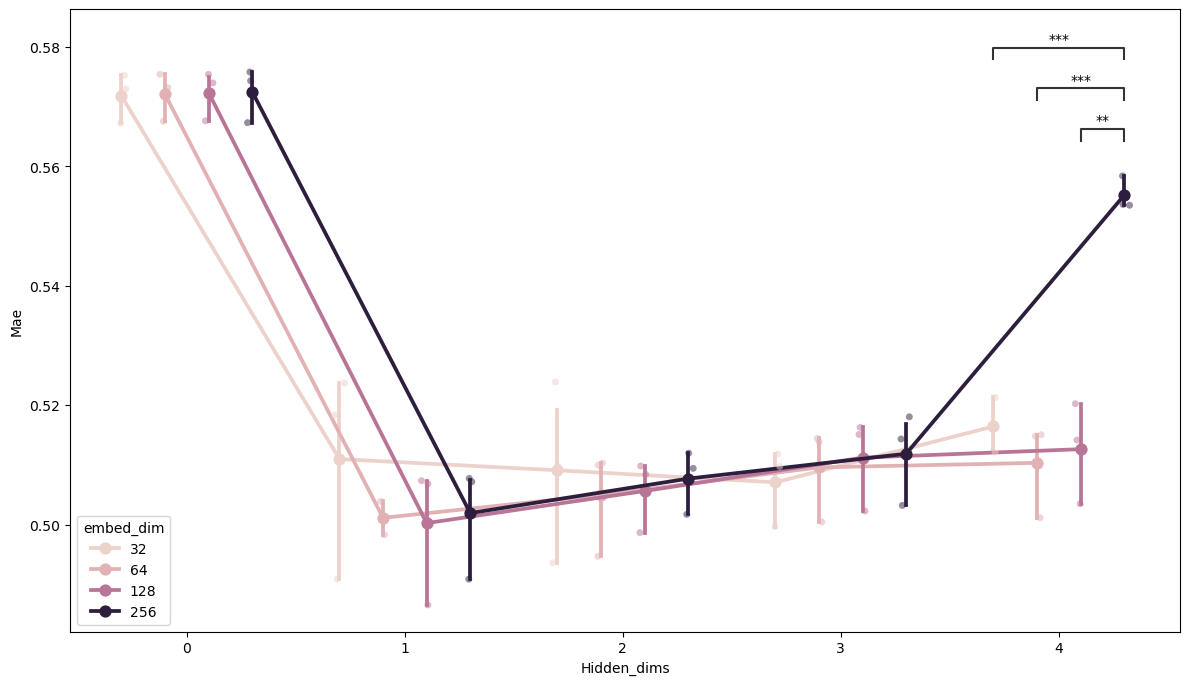

In [8]:
metric_x_point(
    df=test, 
    cols=['embed_dim','hidden_dims'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig='within',
    hue=True
)

In [9]:
from modules.viz import devplot

In [10]:
# dev['loss_weights'] = dev['loss_weights'].astype(str)
# dev

In [11]:
summary = pd.read_csv(folder/'summary.csv')
summary = pd.merge(confs,summary,on='config')
# summary['loss_weights'] = summary['loss_weights'].astype(str)
summary


,embed_dim,hidden_dims,config,metric,mean,sd,ci
0,32,0,embeddim32_hiddendims0,best_epoch,194.333333,39.170567,97.305083
1,32,0,embeddim32_hiddendims0,loss,0.237781,0.038197,0.094888
2,32,0,embeddim32_hiddendims0,mae,0.571795,0.004107,0.010202
3,32,0,embeddim32_hiddendims0,mse,0.708651,0.013894,0.034514
4,32,0,embeddim32_hiddendims0,num_epochs,221.000000,57.166424,142.009269
...,...,...,...,...,...,...,...
155,256,4,embeddim256_hiddendims4,mse,0.694023,0.003528,0.008765
156,256,4,embeddim256_hiddendims4,num_epochs,125.000000,16.522712,41.044691
157,256,4,embeddim256_hiddendims4,r2,0.819648,0.001215,0.003019
158,256,4,embeddim256_hiddendims4,rmse,0.833078,0.002117,0.005259


In [12]:
figs = devplot(
    dev=dev,
    summary=summary,
    metrics=['loss','mse','rmse','r2','mae']
)

In [13]:
for key in figs.keys():
    print(key)

embeddim32_hiddendims0
embeddim32_hiddendims1
embeddim32_hiddendims2
embeddim32_hiddendims3
embeddim32_hiddendims4
embeddim64_hiddendims0
embeddim64_hiddendims1
embeddim64_hiddendims2
embeddim64_hiddendims3
embeddim64_hiddendims4
embeddim128_hiddendims0
embeddim128_hiddendims1
embeddim128_hiddendims2
embeddim128_hiddendims3
embeddim128_hiddendims4
embeddim256_hiddendims0
embeddim256_hiddendims1
embeddim256_hiddendims2
embeddim256_hiddendims3
embeddim256_hiddendims4


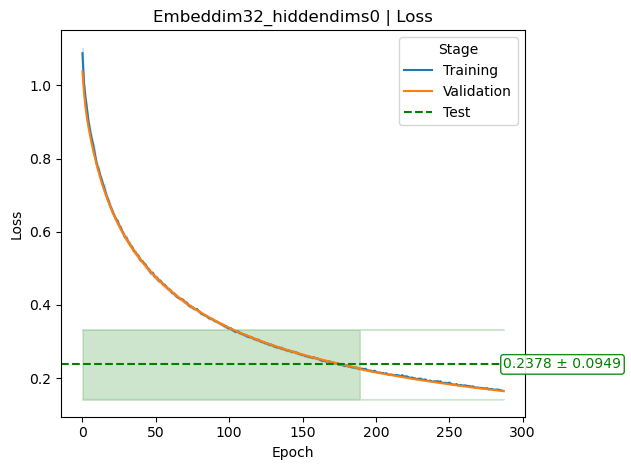

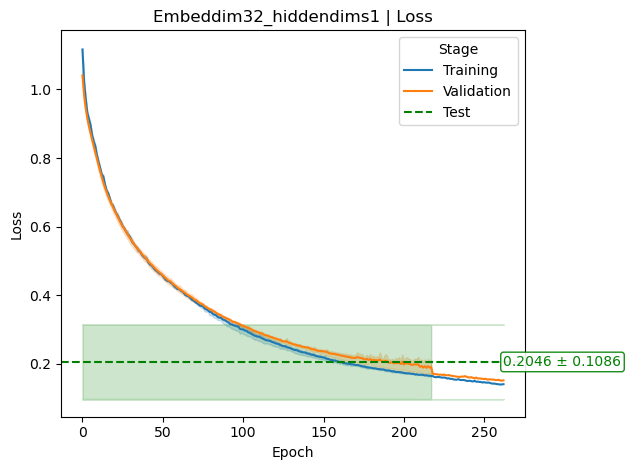

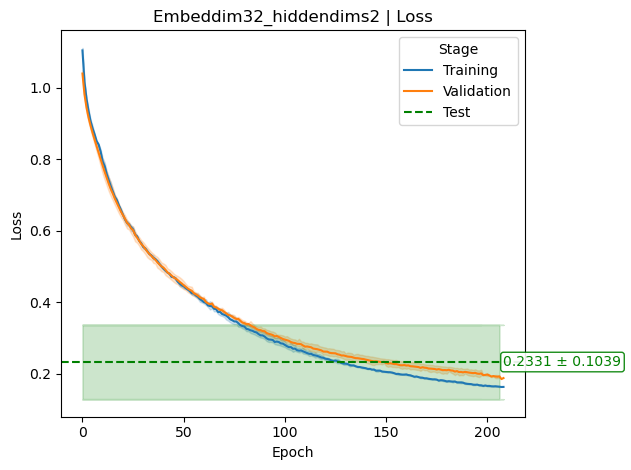

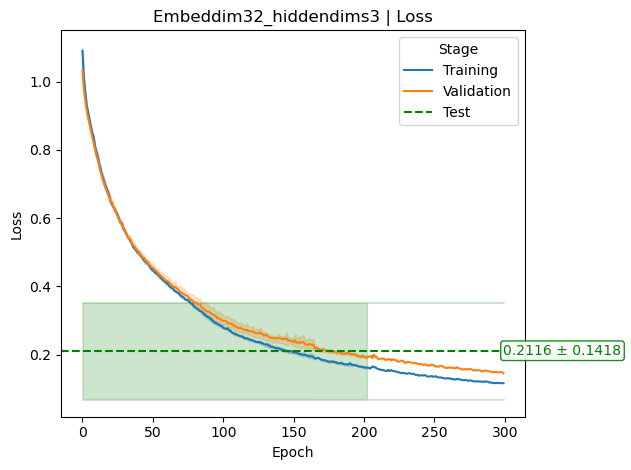

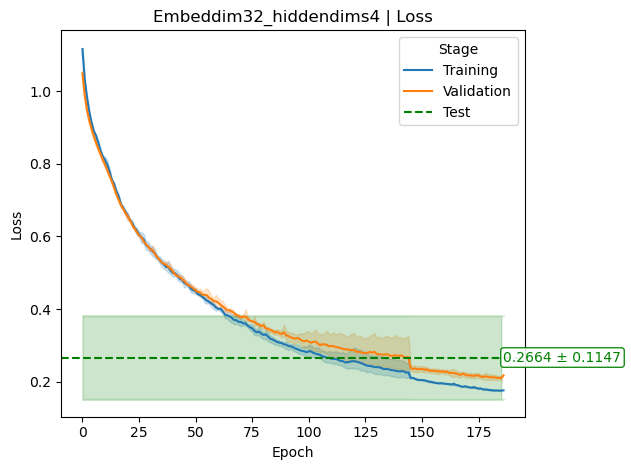

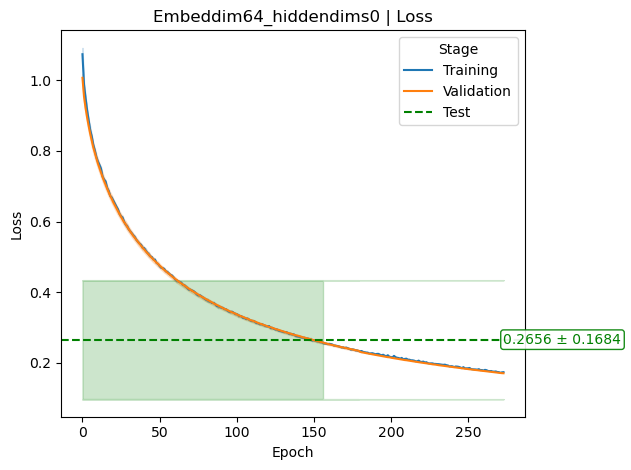

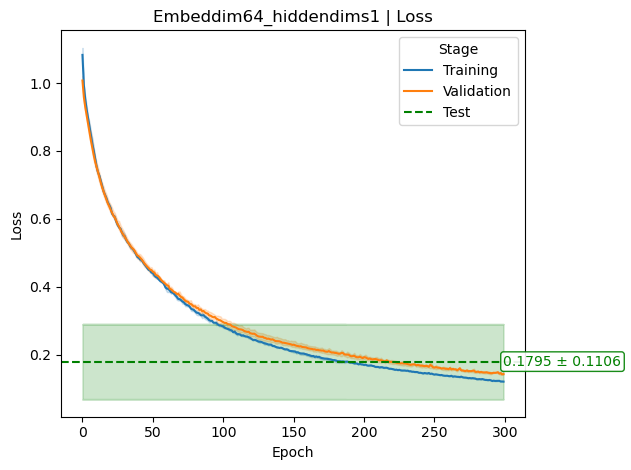

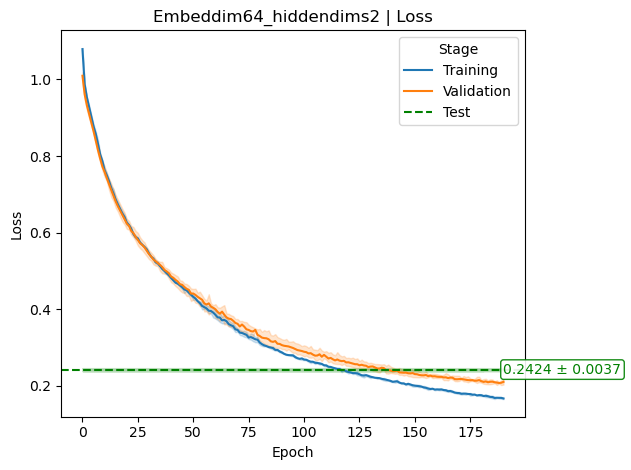

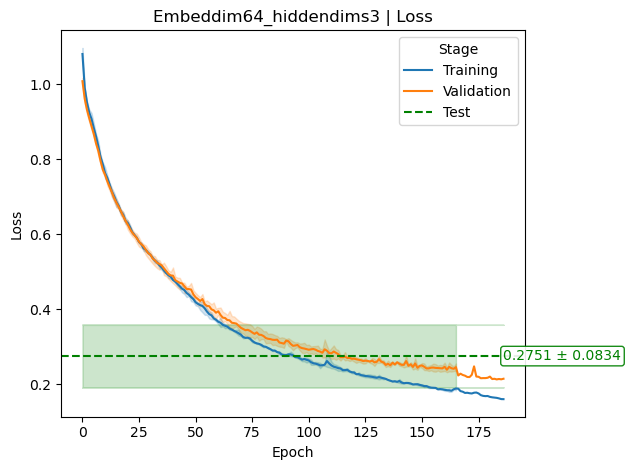

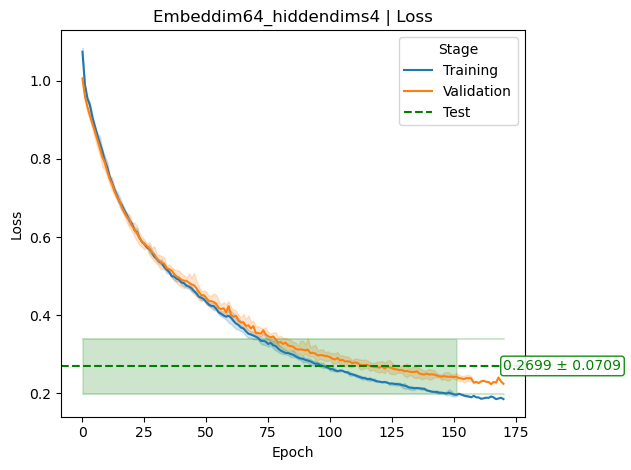

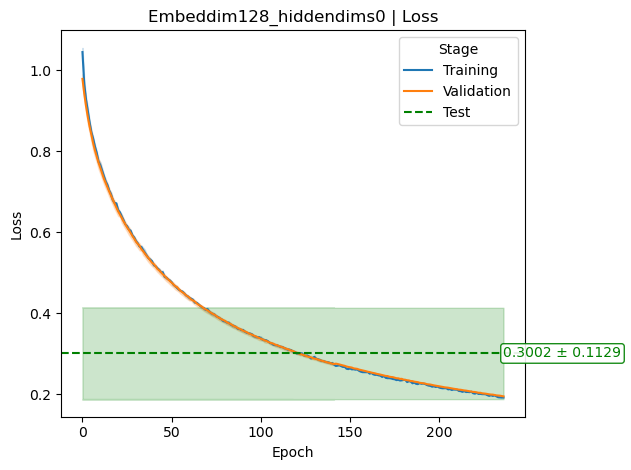

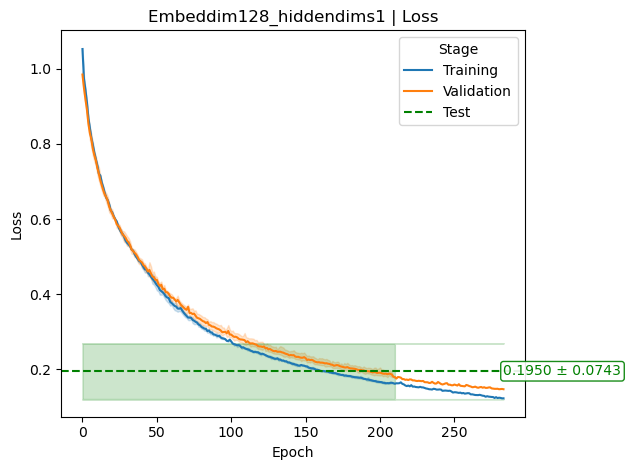

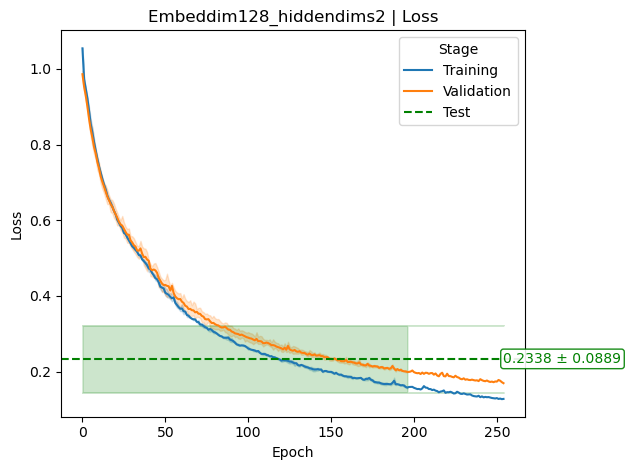

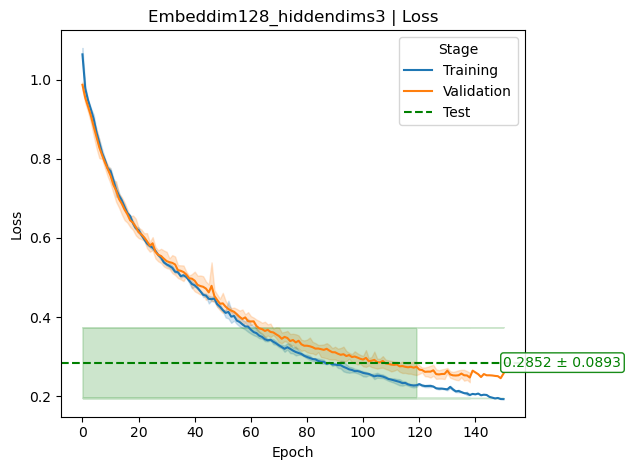

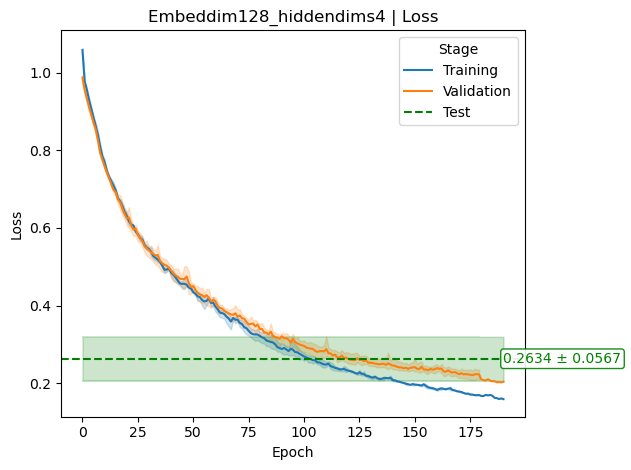

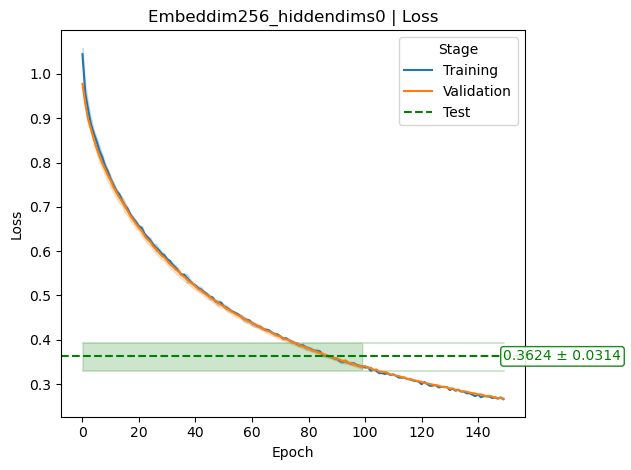

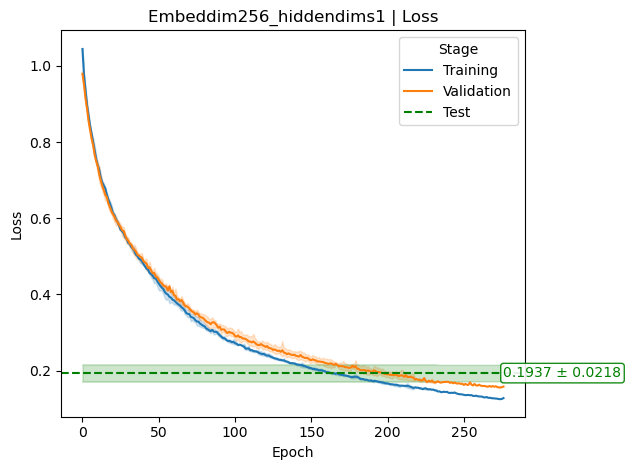

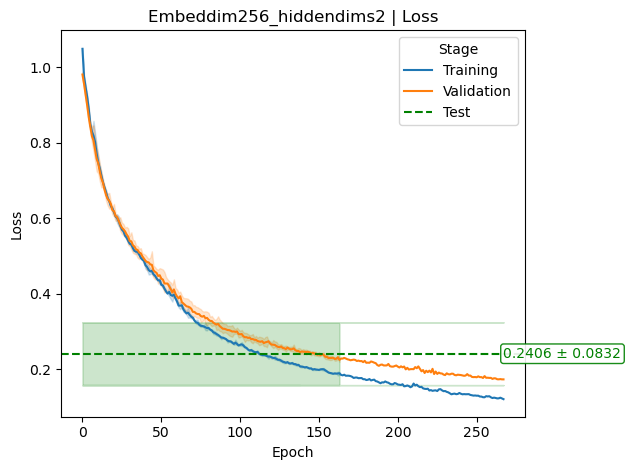

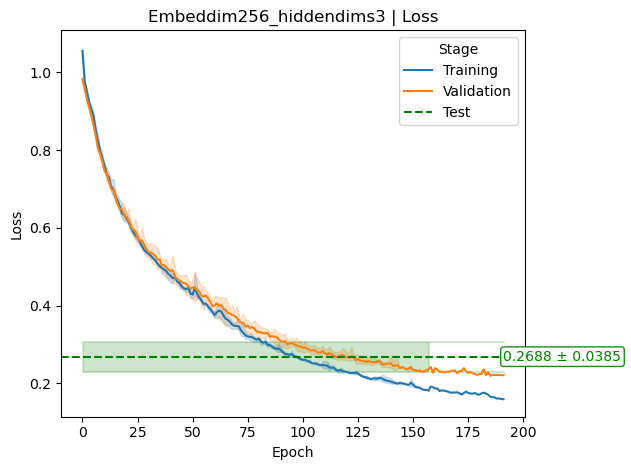

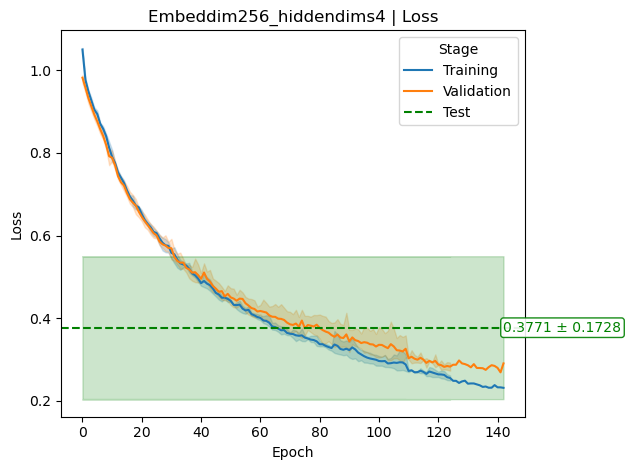

In [14]:
for key in figs.keys():
    display(figs[key]['loss'])

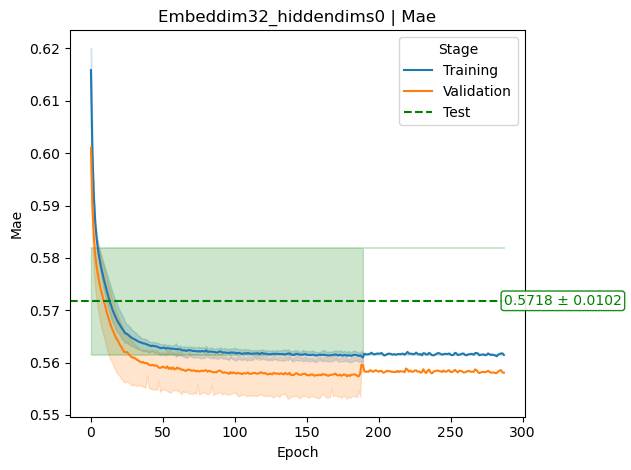

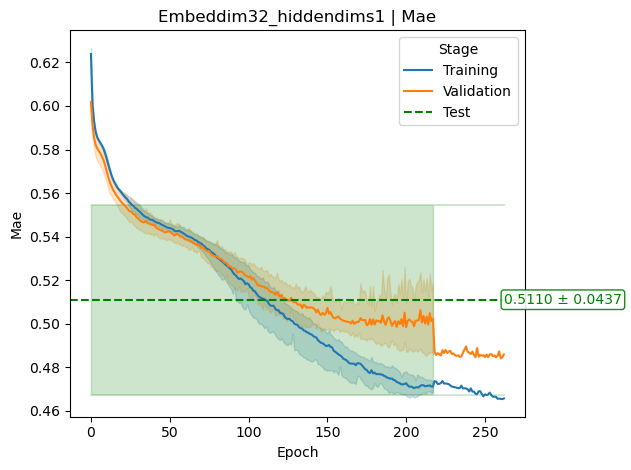

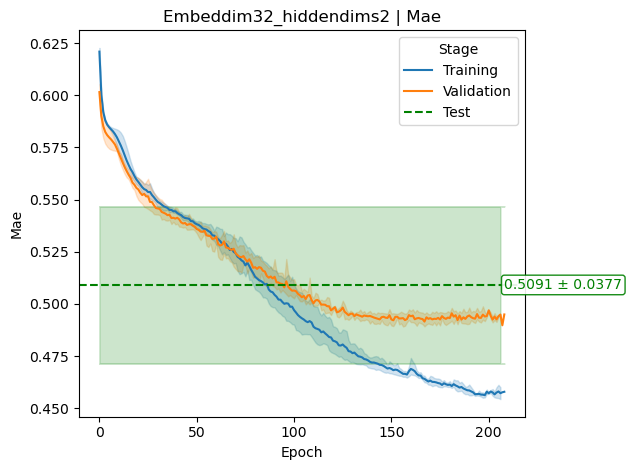

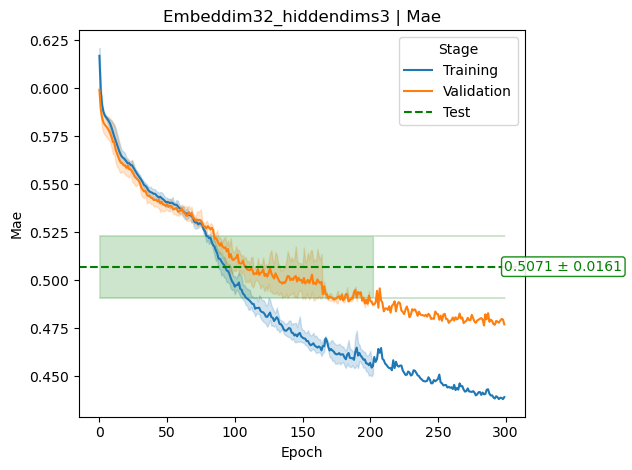

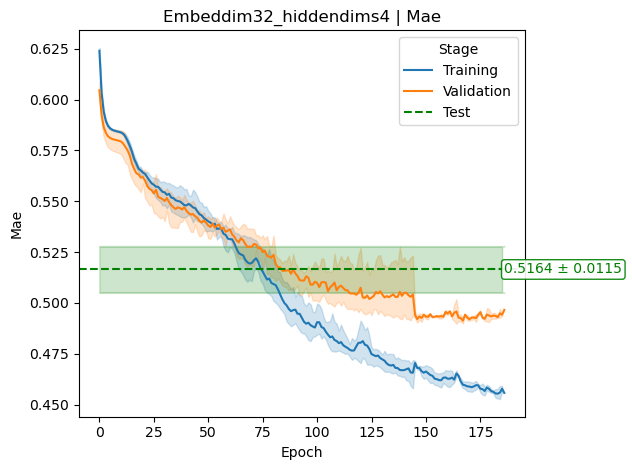

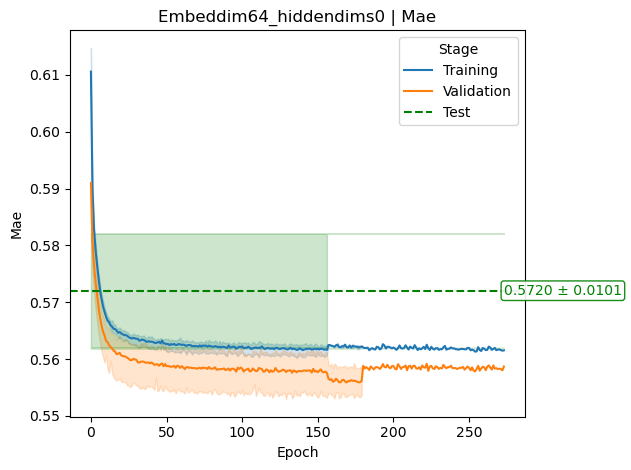

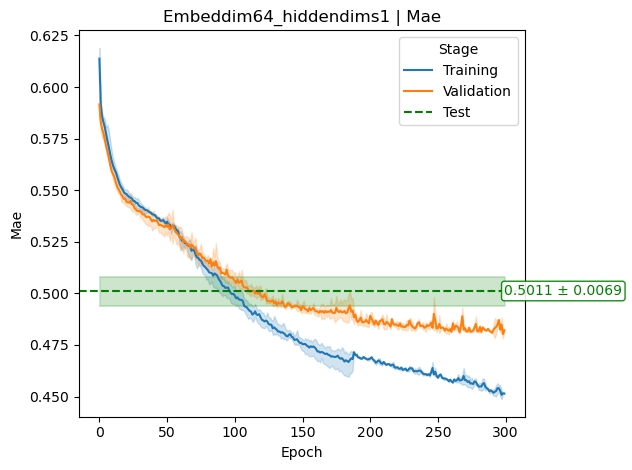

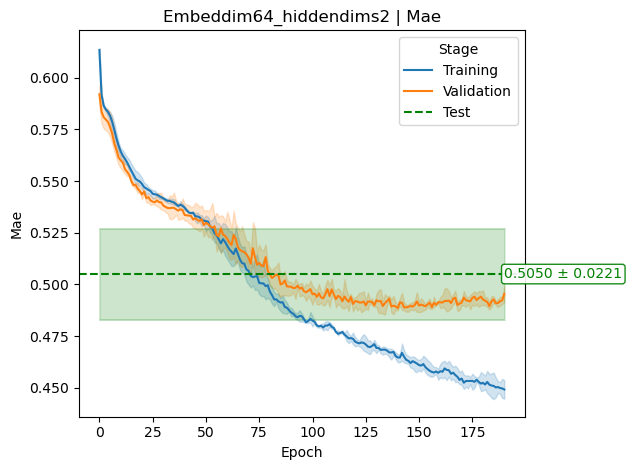

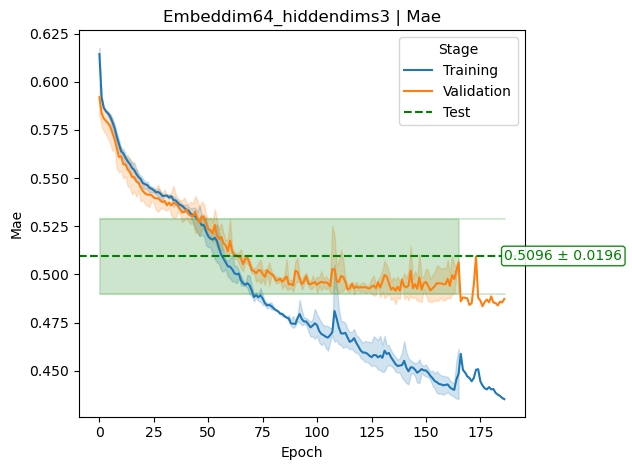

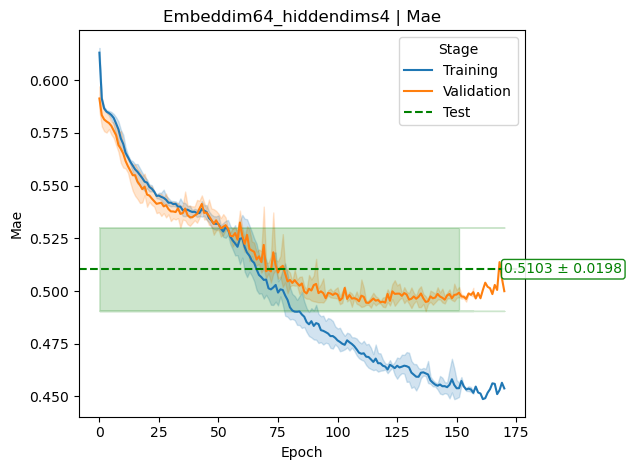

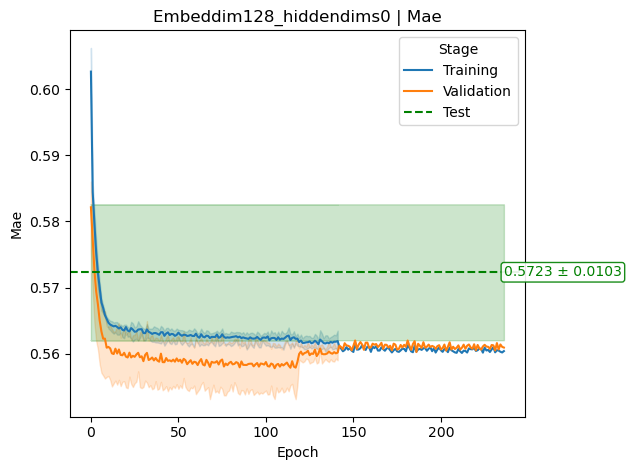

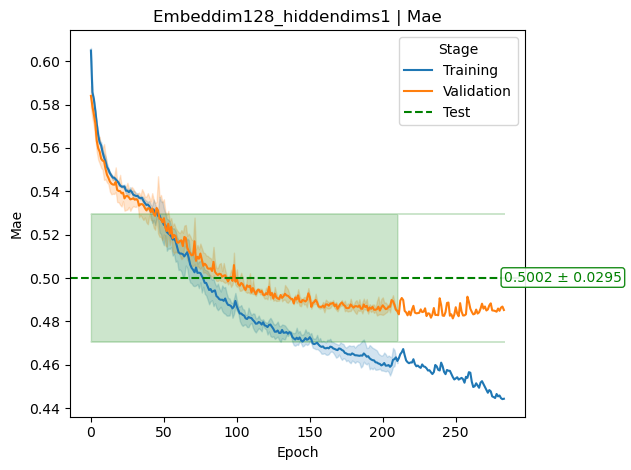

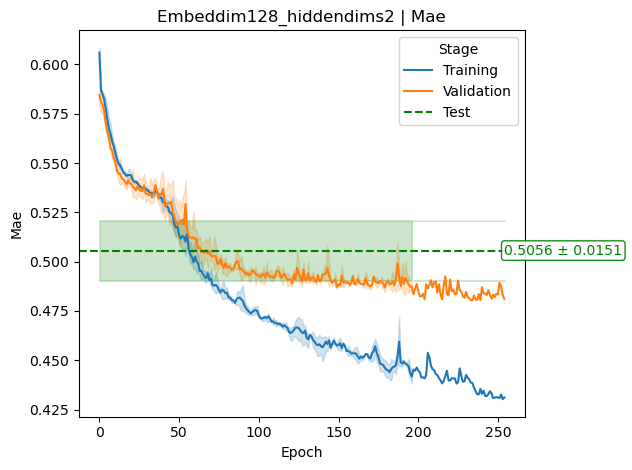

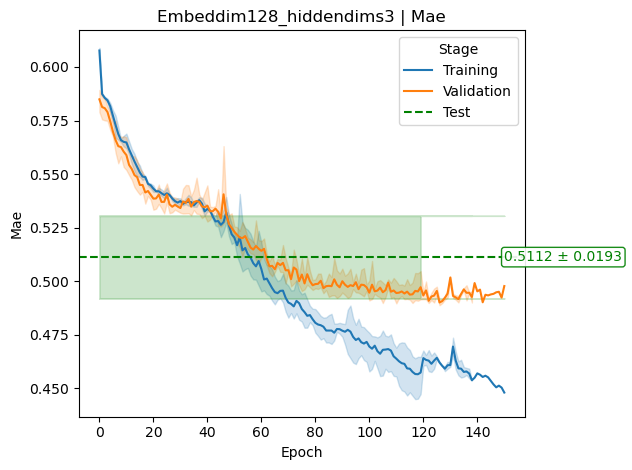

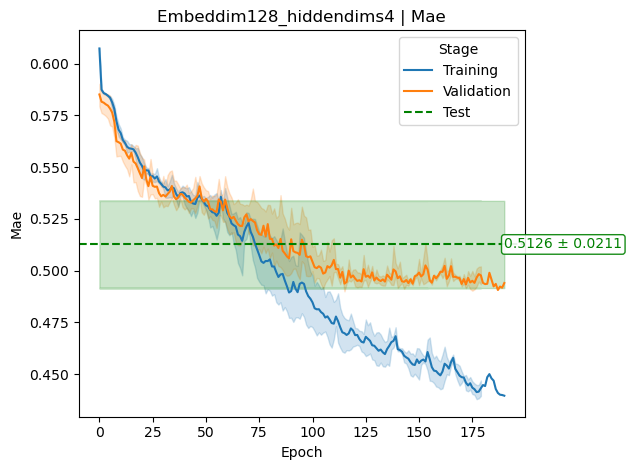

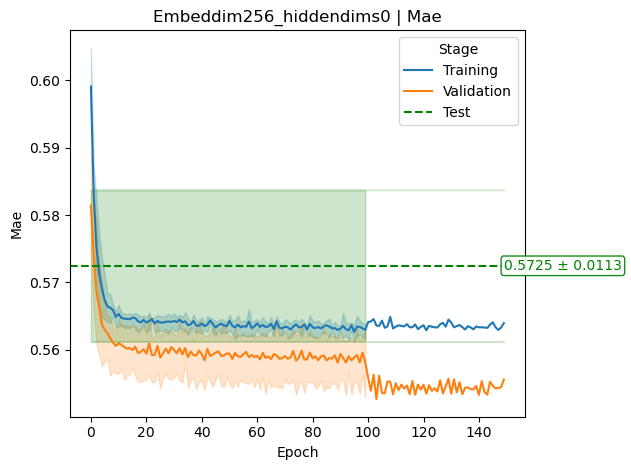

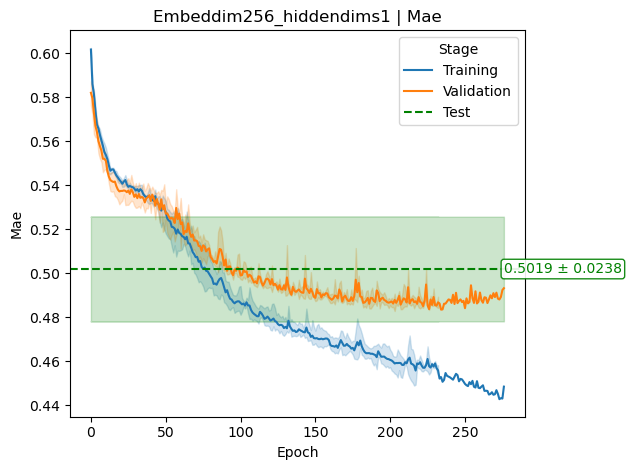

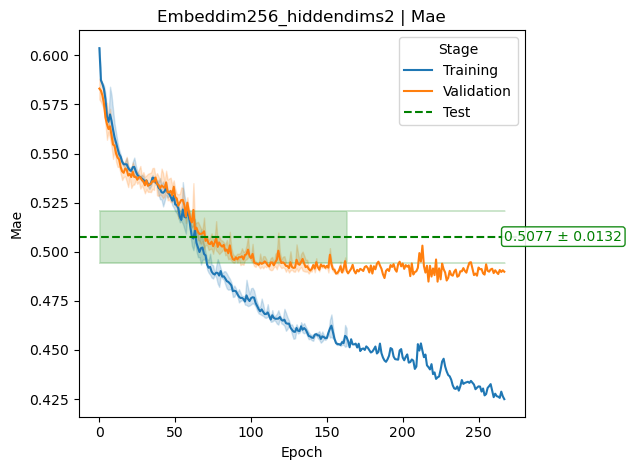

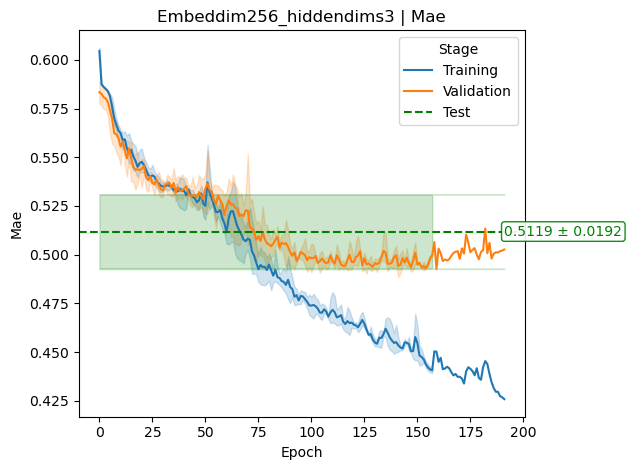

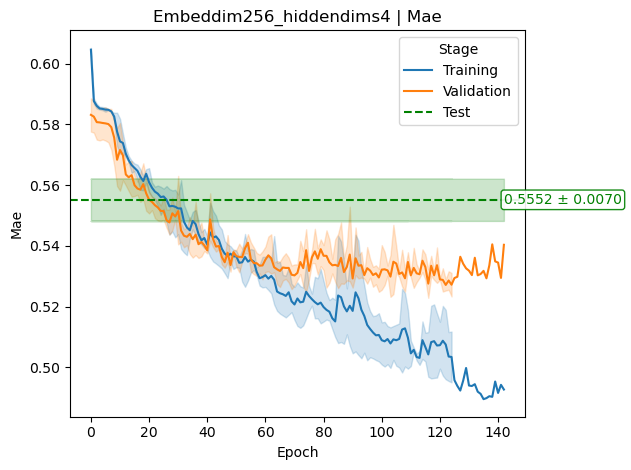

In [15]:
for key in figs.keys():
    display(figs[key]['mae'])

In [16]:
dev

,embed_dim,hidden_dims,config,trial,epoch,stage,metric,value
0,32,0,embeddim32_hiddendims0,0,0,Training,loss,1.059852
1,32,0,embeddim32_hiddendims0,0,0,Training,mse,0.805061
2,32,0,embeddim32_hiddendims0,0,0,Training,rmse,0.897252
3,32,0,embeddim32_hiddendims0,0,0,Training,mae,0.609862
4,32,0,embeddim32_hiddendims0,0,0,Training,r2,0.789984
...,...,...,...,...,...,...,...,...
113455,256,4,embeddim256_hiddendims4,2,142,Validation,loss,0.290713
113456,256,4,embeddim256_hiddendims4,2,142,Validation,mse,0.664888
113457,256,4,embeddim256_hiddendims4,2,142,Validation,rmse,0.815407
113458,256,4,embeddim256_hiddendims4,2,142,Validation,mae,0.540341


In [17]:
dev2 = pd.read_csv(folder/'dev.csv')
dev2

,trial,config,epoch,stage,metric,value
0,0,embeddim32_hiddendims0,0,train,loss,1.059852
1,0,embeddim32_hiddendims0,0,train,mse,0.805061
2,0,embeddim32_hiddendims0,0,train,rmse,0.897252
3,0,embeddim32_hiddendims0,0,train,mae,0.609862
4,0,embeddim32_hiddendims0,0,train,r2,0.789984
...,...,...,...,...,...,...
113455,2,embeddim256_hiddendims4,142,val,loss,0.290713
113456,2,embeddim256_hiddendims4,142,val,mse,0.664888
113457,2,embeddim256_hiddendims4,142,val,rmse,0.815407
113458,2,embeddim256_hiddendims4,142,val,mae,0.540341


In [18]:
dev2.columns

Index(['trial', 'config', 'epoch', 'stage', 'metric', 'value'], dtype='object')

In [19]:
dev2.columns.drop(['trial','value']).tolist()

['config', 'epoch', 'stage', 'metric']

In [20]:
def best_epoch_per_trial(
    df: pd.DataFrame,
    metric: str,
    stage: str = "val",
    mode: str = "min",   # "min" or "max"
):
    d = df[(df["metric"] == metric) & (df["stage"] == stage)].copy()

    # idx of best row within each (trial, config)
    g = d.groupby(["trial", "config"])["value"]
    idx = g.idxmin() if mode == "min" else g.idxmax()

    # get best epoch per trial
    d = d.loc[idx].sort_values(["config", "trial"]).reset_index(drop=True)

    # summarize
    cols = d.columns.drop(['trial', 'epoch', 'value']).tolist()
    d = d.groupby(cols, as_index=False).agg(
        mean_epoch=('epoch','mean'),
        std_epoch=('epoch','std'),
        mean_value=('value','mean'),
        std_value=('value','std'),
        count=('value','count'),
    )

    return d

In [21]:
best_epoch_per_trial(dev2, 'mae')

,config,stage,metric,mean_epoch,std_epoch,mean_value,std_value,count
0,embeddim128_hiddendims0,val,mae,137.000000,42.673177,0.557293,0.003707,3
1,embeddim128_hiddendims1,val,mae,212.000000,31.749016,0.483282,0.002051,3
2,embeddim128_hiddendims2,val,mae,172.333333,57.761002,0.484716,0.003716,3
3,embeddim128_hiddendims3,val,mae,123.333333,20.132892,0.491326,0.003371,3
4,embeddim128_hiddendims4,val,mae,140.333333,31.069814,0.491484,0.002364,3
5,embeddim256_hiddendims0,val,mae,96.333333,7.023769,0.557528,0.004410,3
6,embeddim256_hiddendims1,val,mae,212.000000,12.288206,0.484004,0.001685,3
7,embeddim256_hiddendims2,val,mae,165.666667,53.528808,0.488141,0.003172,3
8,embeddim256_hiddendims3,val,mae,136.333333,5.033223,0.491501,0.003243,3
9,embeddim256_hiddendims4,val,mae,94.000000,30.643107,0.526757,0.003366,3


In [22]:
def dev_summary(df:pd.DataFrame):
    cols = df.columns.drop(['trial','value']).tolist()
    return df.groupby(cols, as_index=False).agg(
        mean=('value','mean'),
        std=('value','std'),
        count=('value','count'),
    )

dev2s = dev_summary(dev2)
dev2s

,config,epoch,stage,metric,mean,std,count
0,embeddim128_hiddendims0,0,train,loss,1.045117,0.009530,3
1,embeddim128_hiddendims0,0,train,mae,0.602652,0.003359,3
2,embeddim128_hiddendims0,0,train,mse,0.784387,0.009702,3
3,embeddim128_hiddendims0,0,train,r2,0.794734,0.002696,3
4,embeddim128_hiddendims0,0,train,rmse,0.885645,0.005477,3
...,...,...,...,...,...,...,...
45175,embeddim64_hiddendims4,170,val,loss,0.224118,NaN,1
45176,embeddim64_hiddendims4,170,val,mae,0.499920,NaN,1
45177,embeddim64_hiddendims4,170,val,mse,0.572798,NaN,1
45178,embeddim64_hiddendims4,170,val,r2,0.851148,NaN,1


In [23]:
dev2s[(dev2s['stage']=='val') & (dev2s['metric']=='mae')]

,config,epoch,stage,metric,mean,std,count
6,embeddim128_hiddendims0,0,val,mae,0.582142,0.005673,3
16,embeddim128_hiddendims0,1,val,mae,0.577373,0.006650,3
26,embeddim128_hiddendims0,2,val,mae,0.572557,0.006894,3
36,embeddim128_hiddendims0,3,val,mae,0.569432,0.006483,3
46,embeddim128_hiddendims0,4,val,mae,0.567453,0.005906,3
...,...,...,...,...,...,...,...
45136,embeddim64_hiddendims4,166,val,mae,0.502889,NaN,1
45146,embeddim64_hiddendims4,167,val,mae,0.500504,NaN,1
45156,embeddim64_hiddendims4,168,val,mae,0.513710,NaN,1
45166,embeddim64_hiddendims4,169,val,mae,0.506036,NaN,1
